<a href="https://colab.research.google.com/github/katsuhiro-wq/katsuhiro-wq/blob/sub1/shunt_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import os

uploader = widgets.FileUpload(
    accept='.wav',  # Accepted file type
    multiple=False  # Only allow single file upload
)
display(uploader)

def on_upload_change(change):
    if uploader.value:
        # Assuming only one file is allowed to be uploaded
        original_filename = list(uploader.value.keys())[0]
        uploaded_file = uploader.value[original_filename]
        audio_data = uploaded_file['content']

        # Rename the file to "audio.wav"
        new_filename = "audio.wav"  # You can change the extension if needed
        with open(new_filename, 'wb') as f:
            f.write(audio_data)

        print(f"File renamed to {new_filename}")

        # Now you can access the file using the new name:
        # with open(new_filename, 'rb') as f:
        #     # Process the audio data here...

    else:
        print("No file uploaded yet.")

uploader.observe(on_upload_change, names='value')

FileUpload(value={}, accept='.wav', description='Upload')

File renamed to audio.wav


# サンプルデータ一つ

実行プログラム

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, iirnotch
import soundfile as sf
import csv
from scipy.signal import get_window
import os
import random
import pandas as pd

# === シャント音の録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # 音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y とサンプリングレート sr を取得
y, sr = librosa.load(filename)  # duration=10をつけると最初の10秒間のみ読み込む

#フィルタ設計から波形出力
# === バンドパスフィルタの設計 ===
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # ナイキスト周波数を計算
    low = lowcut / nyq  # 正規化した低周波数（0〜1の範囲）
    high = highcut / nyq  # 正規化した高周波数（0〜1の範囲）
    b, a = butter(order, [low, high], btype='band')  # バンドパスフィルタの係数を計算
    return b, a
# === ノッチフィルタの設計と適用 ===
def apply_notch_filter(signal, freq, fs, quality_factor=30):
    # ノッチ周波数を正規化（0〜1の範囲）
    w0 = freq / (fs / 2)
    # ノッチフィルタの係数を計算
    b, a = iirnotch(w0, quality_factor)
    # フィルタを適用してノッチング
    y_notched = lfilter(b, a, signal)
    return y_notched
# === フィルタリングの適用 ===
# フィルタのパラメータ設定
lowcut = 100.0  # 低周波数カットオフ（Hz）
highcut = 2400  # 高周波数カットオフ（Hz）

# バンドパスフィルタを設計し、信号に適用
b, a = butter_bandpass(lowcut, highcut, sr, order=5)
y_filtered = lfilter(b, a, y)

# ノッチフィルタの適用（例として50Hzを除去）
notch_freq = 60.0  # ノッチフィルタの周波数（Hz）
y_filtered = apply_notch_filter(y_filtered, notch_freq, sr)

# === フィルタ処理後の波形をWAV形式で保存 ===
#output_filename = "filtered_shunt_sound.wav"  # 出力ファイル名
#sf.write(output_filename, y_filtered, sr)  # 波形データをWAVファイルとして保存

#print(f"{output_filename} を保存しました。")

# オリジナルの波形をプロットするために、yをy_originalに代入
y_original = y

# Hann窓を適用
window = get_window('hann', len(y_filtered))
y_windowed = y_filtered * window

# FFTを実行
fft_result = np.fft.fft(y_windowed)
fft_freqs = np.fft.fftfreq(len(fft_result), d=1/sr)

# === MFCC（メル周波数ケプストラム係数）の計算 ===
mfccs = librosa.feature.mfcc(y=y_filtered, sr=sr, n_mfcc=13)  # 13次のMFCCを計算

# === 特徴量の抽出（MFCCの係数やFFTのピークなど） ===
# ピーク周波数を計算（振幅が最大の周波数）
peak_idx = np.argmax(np.abs(fft_result[:len(fft_result)//2]))  # 正の周波数成分のみを考慮
peak_frequency = fft_freqs[peak_idx]

# MFCCの平均値を計算（各係数ごと）
mfcc_mean = np.mean(mfccs, axis=1)

with open('features.csv', 'w', newline='') as csvfile:
       writer = csv.writer(csvfile)
       writer.writerow(['peak_frequency'] + [f'mfcc_{i}' for i in range(13)])  # ヘッダー行
       writer.writerow([peak_frequency] + list(mfcc_mean))  # 特徴量データ

#print(f"Peak Frequency: {peak_frequency:.2f} Hz")
#print(f"MFCC Mean Coefficients: {mfcc_mean}")

#周波数帯域を200Hz毎に分割し、ピーク値を検出する
def extract_peak_values_and_frequencies(fft_result, fft_freqs, freq_bands):

    peak_values = []
    peak_frequencies = []
    for i in range(len(freq_bands) - 1):
        # 各周波数帯域のインデックスを取得
        band_indices = np.where((fft_freqs >= freq_bands[i]) & (fft_freqs < freq_bands[i + 1]))[0]

        # 帯域内の最大振幅値をピーク値として抽出
        if len(band_indices) > 0:  # 帯域内にデータが存在する場合のみピーク値と周波数を計算
            peak_index_in_band = np.argmax(np.abs(fft_result[band_indices]))  # 帯域内でのピークのインデックス
            peak_index_global = band_indices[peak_index_in_band]  # 全体でのピークのインデックス
            peak_value = np.abs(fft_result[peak_index_global])
            peak_frequency = fft_freqs[peak_index_global]
        else:
            peak_value = 0  # 帯域内にデータが存在しない場合はピーク値を0とする
            peak_frequency = 0  # 周波数も0とする

        peak_values.append(peak_value)
        peak_frequencies.append(peak_frequency)

    return peak_values, peak_frequencies

# 使用例
# fft_result, fft_freqs, freq_bands は事前に計算されているものとする
freq_bands = np.arange(0, sr/2, 200)  # 0Hzからナイキスト周波数まで200Hz刻みで分割
peak_values, peak_frequencies = extract_peak_values_and_frequencies(fft_result, fft_freqs, freq_bands)

# ピーク値が0.1未満のデータを削除
filtered_peak_values = []
filtered_peak_frequencies = []
for value, freq in zip(peak_values, peak_frequencies):
    if value >= 0.1:
        filtered_peak_values.append(value)
        filtered_peak_frequencies.append(freq)

# CSVファイルに保存
with open('peak_data.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Frequency', 'Peak Value'])  # ヘッダー行
    writer.writerows(zip(filtered_peak_frequencies, filtered_peak_values))  # データ行

print("Peak data saved to peak_data.csv")

# シャント不全の判定
# === 判定部分 ===
threshold_frequency = 500  # シャント不全の周波数基準値（Hz）

# 最大ピーク値を取得
max_peak_value = np.max(np.abs(fft_result))

# 500Hz以上の周波数帯域のピーク値を抽出
freq_indices_above_threshold = np.where(fft_freqs >= threshold_frequency)[0]
peak_values_above_threshold = np.abs(fft_result[freq_indices_above_threshold])

# 最大ピーク値の半分以上のピーク値が出現するかどうかを判定
if np.any(peak_values_above_threshold >= max_peak_value / 2):
    print("シャント不全の可能性あり")
else:
    print("正常なシャント音")
import librosa
import numpy as np
import soundfile as sf
import os
import random

# --- データ水増し関数 ---
def augment_audio(y, sr):
  """音声データを水増しする関数"""
  augmented_data = []

  # 1. ノイズの付加
  noise_factor = random.uniform(0.001, 0.01)  # ノイズレベルをランダムに決定
  noise = noise_factor * np.random.randn(len(y))
  augmented_data.append(y + noise)

  # 2. ピッチシフト
  pitch_shift_factor = random.uniform(-2, 2)  # ピッチシフト量をランダムに決定
  pitched_audio = librosa.effects.pitch_shift(y=y, sr=sr, n_steps=pitch_shift_factor)
  augmented_data.append(pitched_audio)

  # 3. タイムストレッチ
  time_stretch_factor = random.uniform(0.9, 1.1)  # タイムストレッチ率をランダムに決定
  stretched_audio = librosa.effects.time_stretch(y, rate=time_stretch_factor)
  augmented_data.append(stretched_audio)

  return augmented_data

# --- データ水増し処理 ---
filename = 'audio.wav'  # 元のシャント音データ
y_original, sr = librosa.load(filename)

num_augmented_files = 100  # 水増しするファイル数

os.makedirs('augmented_data', exist_ok=True)

for i in range(num_augmented_files):
    augmented_audios = augment_audio(y_original, sr)
    for j, y_augmented in enumerate(augmented_audios):
      output_filename = f'augmented_shunt_{i+1:03d}_{j+1}.wav'  # 出力ファイル名
      output_path = os.path.join('augmented_data', output_filename)
      sf.write(output_path, y_augmented, sr)

#シミュレーション生成
# === オリジナルのシャント音録音ファイルを読み込む（10秒間録音） ===
filename = 'audio.wav'  # オリジナル音声ファイルのパス
# librosa.loadで音声ファイルを読み込み、波形データ y_original とサンプリングレート sr を取得
y_original, sr = librosa.load(filename, duration=10)  # duration=10 で最初の10秒間のみを読み込む

# === シミュレーションで似たようなファイルを50個作成 ===

# 出力ディレクトリの設定
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
if not os.path.exists(output_dir):
    os.makedirs(output_dir)  # ディレクトリが存在しない場合は作成

# シミュレーションのパラメータ範囲の設定
noise_levels = np.linspace(0.001, 0.01, 50)  # ノイズレベルの範囲（50段階）
pitch_shift_steps = np.linspace(-2, 2, 50)  # ピッチシフトの範囲（半音単位、50段階）
time_stretch_rates = np.linspace(0.9, 1.1, 50)  # タイムストレッチの範囲（50段階）

# 乱数シードの設定（結果の再現性のため）
np.random.seed(42)

for i in range(50):
    y_simulated = y_original.copy()  # オリジナル音声をコピー

    # === ランダムなノイズを追加 ===
    noise_level = np.random.choice(noise_levels)  # ノイズレベルをランダムに選択
    noise = noise_level * np.random.randn(len(y_simulated))  # ガウスノイズを生成
    y_simulated += noise  # ノイズを音声に追加

    # === ランダムなピッチシフトを適用 ===
    n_steps = np.random.choice(pitch_shift_steps)  # ピッチシフト量をランダムに選択
    # pitch_shift の呼び出しを更新し、必要なパラメータをキーワード引数で渡す
    y_simulated = librosa.effects.pitch_shift(y=y_simulated, sr=sr, n_steps=n_steps)

    # === ランダムなタイムストレッチを適用 ===
    rate = np.random.choice(time_stretch_rates)  # タイムストレッチ率をランダムに選択
    # time_stretch() now expects a dictionary as input
    y_simulated = librosa.effects.time_stretch(y=y_simulated, rate=rate)

    # === シミュレーション音声をファイルに保存 ===
    output_filename = f'simulated_shunt_{i+1:02d}.wav'  # 出力ファイル名を連番で作成
    output_path = os.path.join(output_dir, output_filename)
    sf.write(output_path, y_simulated, sr)  # 音声ファイルを保存

    #print(f"{output_filename} を生成しました。")  # 進行状況を表示

#シミュレーションをラベリング
# === ラベル作成処理 ===
output_dir = 'simulated_shunt_sounds'  # シミュレーション音声の保存先ディレクトリ
#threshold_frequency = 200  # シャント不全の周波数基準（Hz）（例）
#frequency_tolerance = 20  # 許容範囲（Hz）

# ラベルを保存するCSVファイルを開く
with open('ground_truth_labels.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'label'])  # ヘッダー行を書き込む

    for filename in os.listdir(output_dir):
        if filename.endswith('.wav'):
            filepath = os.path.join(output_dir, filename)
            y, sr = librosa.load(filepath)

            # FFT（フーリエ変換）による周波数解析
            fft_result = np.fft.fft(y)  # フーリエ変換を実行
            fft_freqs = np.fft.fftfreq(len(fft_result), d=1 / sr)  # 周波数軸を計算

            # ピーク周波数を計算（振幅が最大の周波数）
            peak_idx = np.argmax(np.abs(fft_result[:len(fft_result) // 2]))  # 正の周波数成分のみを考慮
            peak_frequency = fft_freqs[peak_idx]

            # 最大ピーク値の半分以上のピーク値が500Hz以上に出現するか
            threshold_frequency = 500  # シャント不全の周波数基準値（Hz）
            max_peak_value = np.max(np.abs(fft_result))
            freq_indices_above_threshold = np.where(fft_freqs >= threshold_frequency)[0]
            peak_values_above_threshold = np.abs(fft_result[freq_indices_above_threshold])

            if np.any(peak_values_above_threshold >= max_peak_value / 2):
                label = 'true'  # シャント不全の可能性あり
            else:
                label = 'false'  # 正常なシャント音

            # ファイル名とラベルをCSVファイルに書き込む
            writer.writerow([filename, label])

            # ファイル名とラベルをCSVファイルに書き込む
            writer.writerow([filename, label])

print("ground_truth_labels.csv が作成されました。")

# === 感度と特異度の計算 ===
# 予測ラベルを読み込む (predicted labels) - ここではground_truthと同じものを使用
predicted_labels = {}
with open('ground_truth_labels.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader)  # ヘッダー行をスキップ
    for row in reader:
        predicted_labels[row[0]] = row[1]

# 真陽性 (TP)、偽陽性 (FP)、真陰性 (TN)、偽陰性 (FN) をカウント
TP = FP = TN = FN = 0
for filename in predicted_labels:
    ground_truth = predicted_labels[filename] # ground_truthとpredicted_labelsは同じ
    predicted = predicted_labels[filename]

    if ground_truth == 'true' and predicted == 'true':
        TP += 1
    elif ground_truth == 'false' and predicted == 'true':
        FP += 1
    elif ground_truth == 'false' and predicted == 'false':
        TN += 1
    elif ground_truth == 'true' and predicted == 'false':
        FN += 1

# 感度 (Sensitivity) と特異度 (Specificity) を計算
sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0  # ゼロ除算を回避
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0  # ゼロ除算を回避

print(f"感度 (Sensitivity): {sensitivity:.2f}")
print(f"特異度 (Specificity): {specificity:.2f}")

# Create a DataFrame 'df' with original data and predictions
# You'll need to replace this with your actual data and predictions
data = []
for filename in predicted_labels:
    ground_truth = predicted_labels[filename]  # ground_truth and predicted_labels are the same
    predicted = predicted_labels[filename]
    # Add any other relevant data you want to include in the DataFrame
    data.append([filename, ground_truth, predicted])  # Example: filename, ground truth, prediction

df = pd.DataFrame(data, columns=['filename', 'ground_truth', 'prediction'])

# Displaying results using pandas' display function
results = {'Sensitivity': [sensitivity], 'Specificity': [specificity]}
#print("Sensitivity and Specificity Results:")
display(pd.DataFrame(results, index=[0]))  # Use display instead of ace_tools

# Assuming you have a pandas DataFrame named 'df' with original data and predictions
#print("\nOriginal Data with Predictions:")
display(df)  # Use display instead of ace_tools

# === 特徴量抽出と機械学習による分類 ===
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import librosa.feature

def extract_features(audio_path):
    """音声ファイルから特徴量を抽出する関数"""
    # 音声データの読み込み
    y, sr = librosa.load(audio_path)

    # 各種特徴量の抽出
    # MFCCs (メル周波数ケプストラム係数)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)

    # スペクトル重心
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroids_mean = np.mean(spectral_centroids)

    # スペクトルロールオフ
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_rolloff_mean = np.mean(spectral_rolloff)

    # ゼロ交差率
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    zero_crossing_mean = np.mean(zero_crossing)

    # 特徴量の結合
    features = np.concatenate([
        mfccs_mean,
        [spectral_centroids_mean],
        [spectral_rolloff_mean],
        [zero_crossing_mean]
    ])

    return features

# --- 1. 新しいシャント音データの読み込みと前処理 ---

# Google ドライブ内の新しいデータが保存されているディレクトリへのパス
new_data_dir = '/content/drive/My Drive/研究/シャント音サンプル'  # Google ドライブ内のパス

# 新しいデータの特徴量とラベルを格納するリスト
X_new = []
y_new = []

# 新しいデータのファイル名を格納するリスト
new_filenames = []

for filename in os.listdir(new_data_dir):
       if filename.endswith('.wav'):
           filepath = os.path.join(new_data_dir, filename)

           # --- 前処理 ---
           # 既存の前処理関数 extract_features を使用
           features = extract_features(filepath)
           X_new.append(features)

           # --- ラベルの付与 ---
           # 新しいデータのラベルは手動で設定する必要があります
           # 例： filename に "abnormal" が含まれていれば異常と判定
           label = 1 if "abnormal" in filename else 0  # 異常: 1, 正常: 0
           y_new.append(label)

           new_filenames.append(filename)

# 全音声ファイルの特徴量を抽出
X = []  # 特徴量を格納するリスト
y = []  # ラベルを格納するリスト
filenames = []  # ファイル名を格納するリスト

for dir_name in ['simulated_shunt_sounds', 'augmented_data']:  # シミュレーションデータと水増しデータのディレクトリ
    for filename in os.listdir(dir_name):
        if filename.endswith('.wav'):
            filepath = os.path.join(dir_name, filename)
            # 特徴量の抽出
            features = extract_features(filepath)
            X.append(features)

            # ラベルの取得
            # ファイル名が predicted_labels に存在する場合は、そのラベルを使用します。
            # それ以外の場合は、水増しデータと見なし、ラベルを割り当てます。
            if filename in predicted_labels:
                label = predicted_labels[filename]  # 'true' または 'false'
                y.append(1 if label == 'true' else 0)
            else:
                # 水増しデータは 'false' または '正常' と見なすと仮定します
                y.append(0)  # 必要に応じて 1 に変更できます

            filenames.append(filename)

# リストをNumPy配列に変換
X_new = np.array(X_new)
y_new = np.array(y_new)

# --- 2. データの追加 ---

# 新しいデータのDataFrameを作成
new_data_df = pd.DataFrame({
       'filename': new_filenames,
       'ground_truth': ['true' if label == 1 else 'false' for label in y_new],  # ラベルを文字列に変換
       'prediction': [''] * len(y_new)  # prediction列は空欄で初期化
})

# 既存のDataFrame (df) に新しいデータを結合
df = pd.concat([df, new_data_df], ignore_index=True)

# --- 後の処理 ---
# 既存のデータ (X, y) に新しいデータ (X_new, y_new) を追加
X = np.concatenate([X, X_new])
y = np.concatenate([y, y_new])

# リストをNumPy配列に変換
X = np.array(X)
y = np.array(y)

# データの分割（学習用と検証用）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 特徴量の正規化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ランダムフォレスト分類器の学習
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

# 予測と評価
y_pred = clf.predict(X_test_scaled)

# 分類結果のレポート出力
#print("\n=== Classification Report ===")
#print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))

# 分類結果のレポート出力
print("\n=== Classification Report ===")
# Add the 'labels' parameter to specify the classes present in the data
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Normal', 'Abnormal']))

# 混同行列の出力
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 特徴量の重要度を表示
feature_importance = pd.DataFrame({
    'feature': ['MFCC_' + str(i) for i in range(13)] +
              ['spectral_centroid', 'spectral_rolloff', 'zero_crossing_rate'],
    'importance': clf.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

# モデルの保存
import joblib
joblib.dump(clf, 'shunt_sound_classifier.joblib')
joblib.dump(scaler, 'feature_scaler.joblib')

print("\nモデルが 'shunt_sound_classifier.joblib' として保存されました。")
print("特徴量スケーラーが 'feature_scaler.joblib' として保存されました。")

# 新しい音声ファイルを分類する関数
def classify_new_sound(audio_path):
    """新しい音声ファイルを分類する関数"""
    # 特徴量の抽出
    features = extract_features(audio_path)

    # 特徴量の正規化
    features_scaled = scaler.transform(features.reshape(1, -1))

    # 予測
    prediction = clf.predict(features_scaled)
    probability = clf.predict_proba(features_scaled)

    return {
        'prediction': 'Abnormal' if prediction[0] == 1 else 'Normal',
        'probability': probability[0]
    }


import librosa
import numpy as np
import joblib
import os

# 学習済みモデルとスケーラーの読み込み
clf = joblib.load('shunt_sound_classifier.joblib')
scaler = joblib.load('feature_scaler.joblib')

def classify_shunt_sound(audio_path):
    """新しい音声ファイルを分類する関数"""
    # 特徴量の抽出 (既存の extract_features 関数を使用)
    features = extract_features(audio_path)

    # 特徴量の正規化
    features_scaled = scaler.transform(features.reshape(1, -1))

    # 予測
    prediction = clf.predict(features_scaled)

    # 結果の出力
    if prediction[0] == 1:
        result = "シャント不全の可能性あり"
    else:
        result = "正常なシャント音"

    return result

# 使用例
# Replace with the actual path to your new audio file
new_audio_file = "simulated_shunt_sounds/simulated_shunt_01.wav"  # 分類したい新しい音声ファイルへのパス

# Check if the file exists before attempting to classify
if os.path.exists(new_audio_file):
    result = classify_shunt_sound(new_audio_file)
    print(f"判定結果: {result}")
else:
    print(f"Error: File not found at path: {new_audio_file}")

Peak data saved to peak_data.csv
正常なシャント音
ground_truth_labels.csv が作成されました。
感度 (Sensitivity): 0.00
特異度 (Specificity): 1.00


,Sensitivity,Specificity
0,0,1.0


,filename,ground_truth,prediction
0,simulated_shunt_20.wav,false,false
1,simulated_shunt_39.wav,false,false
2,simulated_shunt_32.wav,false,false
3,simulated_shunt_22.wav,false,false
4,simulated_shunt_37.wav,false,false
5,simulated_shunt_11.wav,false,false
6,simulated_shunt_50.wav,false,false
7,simulated_shunt_01.wav,false,false
8,simulated_shunt_03.wav,false,false
9,simulated_shunt_12.wav,false,false



=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        73
    Abnormal       0.00      0.00      0.00         0

    accuracy                           1.00        73
   macro avg       0.50      0.50      0.50        73
weighted avg       1.00      1.00      1.00        73


=== Confusion Matrix ===
[[73]]

=== Feature Importance ===
               feature  importance
0               MFCC_0         0.0
1               MFCC_1         0.0
2               MFCC_2         0.0
3               MFCC_3         0.0
4               MFCC_4         0.0
5               MFCC_5         0.0
6               MFCC_6         0.0
7               MFCC_7         0.0
8               MFCC_8         0.0
9               MFCC_9         0.0
10             MFCC_10         0.0
11             MFCC_11         0.0
12             MFCC_12         0.0
13   spectral_centroid         0.0
14    spectral_rolloff         0.0
15  zero_crossing_rat

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

# classify_shunt_sound 関数を定義する
# ... (既存の classify_shunt_sound 関数のコードをここに貼り付ける) ...

# Google ドライブ内のシャント音サンプルのディレクトリへのパス
shunt_sound_dir = '/content/drive/My Drive/研究/シャント音サンプル'

# 結果を格納するリスト
results = []

# Google ドライブ内の .wav ファイルをループ処理する
for filename in os.listdir(shunt_sound_dir):
    if filename.endswith('.wav'):
        filepath = os.path.join(shunt_sound_dir, filename)
        result = classify_shunt_sound(filepath)  # 分類を実行
        results.append([filename, result])  # 結果をリストに追加

# 結果をデータフレームに追加する
df_results = pd.DataFrame(results, columns=['filename', 'prediction'])

# データフレームを表示する
display(df_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,filename,prediction
0,shunt01_01.wav,正常なシャント音
1,shunt01_02.wav,正常なシャント音
2,shunt01_03.wav,正常なシャント音
3,shunt01_04.wav,正常なシャント音
4,shunt01_05.wav,正常なシャント音
5,shunt01_06.wav,正常なシャント音
6,shunt02_01.wav,正常なシャント音
7,shunt02_02.wav,正常なシャント音
8,shunt02_03.wav,正常なシャント音
9,shunt02_04.wav,正常なシャント音


(73, 1)


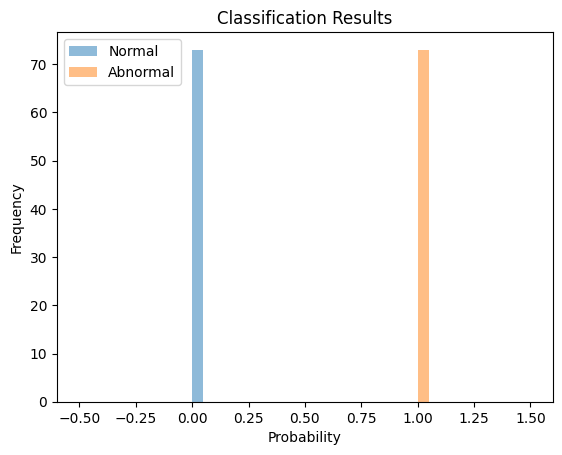

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 分類結果の確率を取得
probabilities = clf.predict_proba(X_test_scaled)

# probabilities の形状を確認
print(probabilities.shape)  # 配列の次元を出力します

# probabilities の形状が (n_samples, 1) の場合、分類器は1つのクラスのみを予測しています
# この場合、この状況を処理するようにコードを変更する必要があります
if probabilities.shape[1] == 1:
    # 1列しかない場合は、正のクラスの確率を表している可能性があります
    # 負のクラスの確率は 1 - 正のクラスの確率と仮定します
    normal_probs = 1 - probabilities[:, 0]  # 「正常」の確率
    abnormal_probs = probabilities[:, 0]    # 「異常」の確率
else:
    # 2列ある場合は、両方のクラスの確率を表していると考えられます
    normal_probs = probabilities[:, 0]
    abnormal_probs = probabilities[:, 1]

# ヒストグラムを作成
plt.hist(normal_probs, bins=20, alpha=0.5, label='Normal')
plt.hist(abnormal_probs, bins=20, alpha=0.5, label='Abnormal')

# グラフの装飾
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Classification Results')
plt.legend()

# グラフを表示
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, iirnotch
import soundfile as sf
import csv
from scipy.signal import get_window
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import librosa.feature
import joblib


def preprocess_audio(filename):
    """音声ファイルの前処理を行う関数"""
    # 音声データの読み込み
    y, sr = librosa.load(filename)

    # バンドパスフィルターの設計と適用
    lowcut = 100.0
    highcut = 2400
    b, a = butter_bandpass(lowcut, highcut, sr, order=5)
    y_filtered = lfilter(b, a, y)

    # ノッチフィルターの適用
    notch_freq = 60.0
    y_filtered = apply_notch_filter(y_filtered, notch_freq, sr)

    return y_filtered, sr


def extract_features(audio_path):
    """音声ファイルから特徴量を抽出する関数"""
    # 音声データの読み込み
    y, sr = librosa.load(audio_path)

    # 各種特徴量の抽出
    # MFCCs (メル周波数ケプストラム係数)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)

    # スペクトル重心
    spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroids_mean = np.mean(spectral_centroids)

    # スペクトルロールオフ
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    spectral_rolloff_mean = np.mean(spectral_rolloff)

    # ゼロ交差率
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    zero_crossing_mean = np.mean(zero_crossing)

    # 特徴量の結合
    features = np.concatenate([
        mfccs_mean,
        [spectral_centroids_mean],
        [spectral_rolloff_mean],
        [zero_crossing_mean]
    ])

    return features

# --- 3. データ拡張とシミュレーションデータ生成 ---
def augment_and_simulate_data(filename, num_augmented_files=100):
    """
    データ拡張とシミュレーションデータ生成を行う関数

    Args:
        filename (str): 元となる音声ファイルのパス
        num_augmented_files (int, optional): データ拡張で生成するファイル数. Defaults to 100.
    """
    y_original, sr = librosa.load(filename)

    # データ拡張
    os.makedirs('augmented_data', exist_ok=True)  # augmented_dataディレクトリを作成
    for i in range(num_augmented_files):
        augmented_audios = augment_audio(y_original, sr)  # 音声データ拡張
        for j, y_augmented in enumerate(augmented_audios):
            output_filename = f'augmented_shunt_{i+1:03d}_{j+1}.wav'  # 出力ファイル名
            output_path = os.path.join('augmented_data', output_filename)  # 出力ファイルパス
            sf.write(output_path, y_augmented, sr)  # ファイル保存

    # シミュレーションデータ生成
    output_dir = 'simulated_shunt_sounds'  # simulated_shunt_soundsディレクトリ
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)  # ディレクトリがなければ作成

    noise_levels = np.linspace(0.001, 0.01, 50)  # ノイズレベルの範囲
    pitch_shift_steps = np.linspace(-2, 2, 50)  # ピッチシフトの範囲
    time_stretch_rates = np.linspace(0.9, 1.1, 50)  # タイムストレッチの範囲

    np.random.seed(42)  # 乱数シード固定

    y_original, sr = librosa.load(filename, duration=10)  # 元の音声データ読み込み (10秒)

    for i in range(50):
        y_simulated = y_original.copy()  # 元の音声データをコピー

        # ランダムなノイズを追加
        noise_level = np.random.choice(noise_levels)  # ノイズレベルをランダムに選択
        noise = noise_level * np.random.randn(len(y_simulated))  # ノイズ生成
        y_simulated += noise  # ノイズを追加

        # ランダムなピッチシフトを適用
        n_steps = np.random.choice(pitch_shift_steps)  # ピッチシフト量をランダムに選択
        y_simulated = librosa.effects.pitch_shift(y=y_simulated, sr=sr, n_steps=n_steps)  # ピッチシフト適用

        # ランダムなタイムストレッチを適用
        rate = np.random.choice(time_stretch_rates)  # タイムストレッチ率をランダムに選択
        y_simulated = librosa.effects.time_stretch(y=y_simulated, rate=rate)  # タイムストレッチ適用

        # シミュレーション音声をファイルに保存
        output_filename = f'simulated_shunt_{i+1:02d}.wav'  # 出力ファイル名
        output_path = os.path.join(output_dir, output_filename)  # 出力ファイルパス
        sf.write(output_path, y_simulated, sr)  # ファイル保存

def augment_audio(y, sr):
    """音声データを水増しする関数"""
    augmented_data = []

     # 1. ノイズの付加
    noise_factor = random.uniform(0.001, 0.01)  # ノイズレベルをランダムに決定
    noise = noise_factor * np.random.randn(len(y))
    augmented_data.append(y + noise)

    # 2. ピッチシフト
    pitch_shift_factor = random.uniform(-2, 2)  # ピッチシフト量をランダムに決定
    # ピッチシフトを適用する前に、y を浮動小数点数に変換します
    pitched_audio = librosa.effects.pitch_shift(y=y.astype(float), sr=sr, n_steps=pitch_shift_factor)
    augmented_data.append(pitched_audio)

    # 3. タイムストレッチ
    time_stretch_factor = random.uniform(0.9, 1.1)  # タイムストレッチ率をランダムに決定
    # タイムストレッチを適用する前に、y を浮動小数点数に変換します
    stretched_audio = librosa.effects.time_stretch(y.astype(float), rate=time_stretch_factor)
    augmented_data.append(stretched_audio)

    return augmented_data

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs  # ナイキスト周波数を計算
    low = lowcut / nyq  # 正規化した低周波数（0〜1の範囲）
    high = highcut / nyq  # 正規化した高周波数（0〜1の範囲）
    b, a = butter(order, [low, high], btype='band')  # バンドパスフィルタの係数を計算
    return b, a

def apply_notch_filter(signal, freq, fs, quality_factor=30):
    # ノッチ周波数を正規化（0〜1の範囲）
    w0 = freq / (fs / 2)
    # ノッチフィルタの係数を計算
    b, a = iirnotch(w0, quality_factor)
    # フィルタを適用してノッチング
    y_notched = lfilter(b, a, signal)
    return y_notched

def train_and_evaluate_model(X, y):
    """機械学習モデルの学習と評価を行う関数"""
    # データの分割（学習用と検証用）
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 特徴量の正規化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ランダムフォレスト分類器の学習
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_scaled, y_train)

    # 予測と評価
    y_pred = clf.predict(X_test_scaled)

    # 分類結果のレポート出力
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Normal', 'Abnormal']))

    # 混同行列の出力
    print("\n=== Confusion Matrix ===")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # 特徴量の重要度を表示
    feature_importance = pd.DataFrame({
        'feature': ['MFCC_' + str(i) for i in range(13)] + ['spectral_centroid', 'spectral_rolloff', 'zero_crossing_rate'],
        'importance': clf.feature_importances_
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    print("\n=== Feature Importance ===")
    print(feature_importance)

    # モデルの保存
    joblib.dump(clf, 'shunt_sound_classifier.joblib')
    joblib.dump(scaler, 'feature_scaler.joblib')

    print("\nモデルが 'shunt_sound_classifier.joblib' として保存されました。")
    print("特徴量スケーラーが 'feature_scaler.joblib' として保存されました。")

    return clf, scaler

def classify_shunt_sound(audio_path, clf, scaler):
    """新しい音声ファイルを分類する関数"""
    # 特徴量の抽出 (既存の extract_features 関数を使用)
    features = extract_features(audio_path)

    # 特徴量の正規化
    features_scaled = scaler.transform(features.reshape(1, -1))

    # 予測
    prediction = clf.predict(features_scaled)

    # 結果の出力
    if prediction[0] == 1:
        result = "シャント不全の可能性あり"
    else:
        result = "正常なシャント音"

    return result

def main():
    """音声ファイルの分類処理を行うメイン関数"""

    # --- 1. アップロードされた音声ファイルの前処理 ---
    y_filtered, sr = preprocess_audio("audio.wav")  # audio.wav を直接読み込む

    # --- 2. データ拡張とシミュレーション ---
    augment_and_simulate_data("audio.wav")

    # --- 3. 特徴量抽出 ---
    X = []
    y = []
    filenames = []
    for dir_name in ['simulated_shunt_sounds', 'augmented_data']:
        for filename in os.listdir(dir_name):
            if filename.endswith('.wav'):
                filepath = os.path.join(dir_name, filename)
                features = extract_features(filepath)
                X.append(features)
                # ラベル割り当て (仮) - 必要に応じて修正
                y.append(0)  # 正常: 0, 異常: 1
                filenames.append(filename)
    X = np.array(X)
    y = np.array(y)

    # --- 4. モデルの学習と評価 ---
    clf, scaler = train_and_evaluate_model(X, y)

    # --- 5. Google Drive 内の新しい音声ファイルの分類 ---
    from google.colab import drive
    drive.mount('/content/drive')

    shunt_sound_dir = '/content/drive/My Drive/研究/シャント音サンプル'
    for filename in os.listdir(shunt_sound_dir):
        if filename.endswith('.wav'):
            filepath = os.path.join(shunt_sound_dir, filename)
            result = classify_shunt_sound(filepath, clf, scaler)
            print(f"ファイル名: {filename}, 判定結果: {result}")


if __name__ == "__main__":
    main()


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        70
    Abnormal       0.00      0.00      0.00         0

    accuracy                           1.00        70
   macro avg       0.50      0.50      0.50        70
weighted avg       1.00      1.00      1.00        70


=== Confusion Matrix ===
[[70]]

=== Feature Importance ===
               feature  importance
0               MFCC_0         0.0
1               MFCC_1         0.0
2               MFCC_2         0.0
3               MFCC_3         0.0
4               MFCC_4         0.0
5               MFCC_5         0.0
6               MFCC_6         0.0
7               MFCC_7         0.0
8               MFCC_8         0.0
9               MFCC_9         0.0
10             MFCC_10         0.0
11             MFCC_11         0.0
12             MFCC_12         0.0
13   spectral_centroid         0.0
14    spectral_rolloff         0.0
15  zero_crossing_rat

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ファイル名: shunt01_01.wav, 判定結果: 正常なシャント音
ファイル名: shunt01_02.wav, 判定結果: 正常なシャント音
ファイル名: shunt01_03.wav, 判定結果: 正常なシャント音
ファイル名: shunt01_04.wav, 判定結果: 正常なシャント音
ファイル名: shunt01_05.wav, 判定結果: 正常なシャント音
ファイル名: shunt01_06.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_01.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_02.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_03.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_04.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_05.wav, 判定結果: 正常なシャント音
ファイル名: shunt02_06.wav, 判定結果: 正常なシャント音
